# Preprocessing + Gold Standard - Monkeypox Dataset

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = '../../data/processed/'
GOLD_PATH = '../../data/gold_standard/'
FIGURES_PATH = '../../results/figures/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(GOLD_PATH, exist_ok=True)

## 1. Load & Combine

In [2]:
df_main = pd.read_csv('../../data/raw/monkeypox.csv')
df_followup = pd.read_csv('../../data/raw/monkeypox-followup.csv')
df_main['source_file'] = 'main'
df_followup['source_file'] = 'followup'
df = pd.concat([df_main, df_followup], ignore_index=True)

# Normalize labels
df['label'] = df['binary_class'].map({0: 'reliable', 1: 'misinformation'})
df['label_3'] = df['ternary_class'].map({9: 'reliable', 0: 'borderline', 1: 'misinformation'})

print(f'Combined: {len(df):,} rows')
print(df['label'].value_counts())

Combined: 6,287 rows
label
reliable          5124
misinformation    1163
Name: count, dtype: int64


## 2. Clean Text

In [3]:
def clean_tweet(text, max_chars=350):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'^RT\s*[:]?\s*', '', text, flags=re.IGNORECASE)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]

df['cleaned_tweet'] = df['text'].apply(clean_tweet)
df['word_count'] = df['cleaned_tweet'].str.split().str.len()

print(f'Before filter: {len(df):,}')
df = df[df['word_count'] >= 5].drop_duplicates(subset='cleaned_tweet')
print(f'After filter + dedup: {len(df):,}')
print(df['label'].value_counts())

Before filter: 6,287
After filter + dedup: 5,369
label
reliable          4326
misinformation    1043
Name: count, dtype: int64


In [4]:
# Save full clean file
cols = ['number', 'created_at', 'text', 'cleaned_tweet', 'label', 'label_3', 'source_file',
        'retweet_count', 'reply_count', 'like_count', 'quote_count',
        'followers count', 'following count', 'user is verified', 'user has url']
cols = [c for c in cols if c in df.columns]
df[cols].to_csv(f'{PROCESSED_PATH}monkeypox_clean.csv', index=False)
print(f'Saved: monkeypox_clean.csv ({len(df):,} rows)')

Saved: monkeypox_clean.csv (5,369 rows)


## 3. Create Gold Standard

In [5]:
misinfo = df[df['label'] == 'misinformation']
reliable = df[df['label'] == 'reliable'].sample(min(2000, (df['label'] == 'reliable').sum()), random_state=42)

gold = pd.concat([misinfo, reliable], ignore_index=True)
gold = gold.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Gold Standard: {len(gold):,}')
print(gold['label'].value_counts())

train, temp = train_test_split(gold, test_size=0.30, stratify=gold['label'], random_state=42)
val, test = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=42)
print(f'\nTrain: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Gold Standard: 3,043
label
reliable          2000
misinformation    1043
Name: count, dtype: int64

Train: 2,130 | Val: 456 | Test: 457


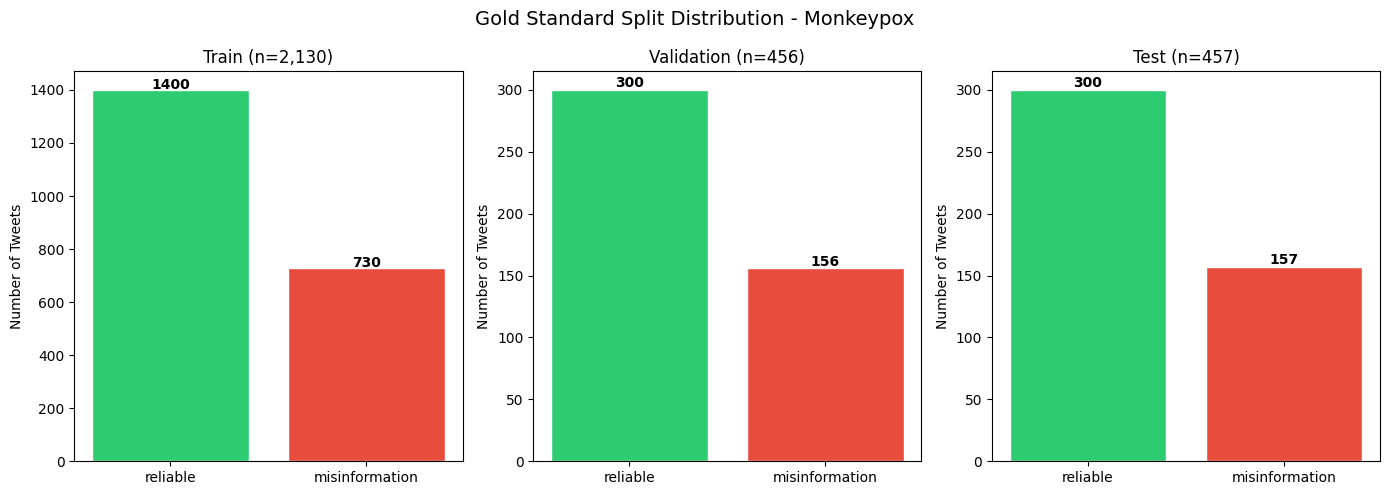

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, split_df, title in [(axes[0], train, 'Train'), (axes[1], val, 'Validation'), (axes[2], test, 'Test')]:
    counts = split_df['label'].value_counts()
    ax.bar(counts.index, counts.values,
           color=['#2ecc71' if x == 'reliable' else '#e74c3c' for x in counts.index],
           edgecolor='white')
    ax.set_title(f'{title} (n={len(split_df):,})', fontsize=12)
    ax.set_ylabel('Number of Tweets')
    for bar, val_ in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val_), ha='center', fontweight='bold')

plt.suptitle('Gold Standard Split Distribution - Monkeypox', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}mpox_07_gold_standard_splits.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
gold.to_csv(f'{GOLD_PATH}monkeypox_gold_standard.csv', index=False)
train.to_csv(f'{GOLD_PATH}monkeypox_train.csv', index=False)
val.to_csv(f'{GOLD_PATH}monkeypox_val.csv', index=False)
test.to_csv(f'{GOLD_PATH}monkeypox_test.csv', index=False)

print('Saved:')
for name, df_ in [('gold_standard', gold), ('train', train), ('val', val), ('test', test)]:
    print(f'  monkeypox_{name}.csv ({len(df_):,} rows)')

Saved:
  monkeypox_gold_standard.csv (3,043 rows)
  monkeypox_train.csv (2,130 rows)
  monkeypox_val.csv (456 rows)
  monkeypox_test.csv (457 rows)


## 4. Sample Examples

In [8]:
print('Misinformation samples:')
print('-'*60)
for _, row in test[test['label'] == 'misinformation'].head(3).iterrows():
    print(f'Original: {str(row["text"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

print('Reliable samples:')
print('-'*60)
for _, row in test[test['label'] == 'reliable'].head(3).iterrows():
    print(f'Original: {str(row["text"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

Misinformation samples:
------------------------------------------------------------
Original: @thierrybaudet study proof monkeypox manmade deliberately released for plandemic _URL_
Cleaned:  study proof monkeypox manmade deliberately released for plandemic URL

Original: @FoxNews Monkey pox seems to be restricted to certain folk engaging in some naughty practices. Am I right? The other thing I heard was that unnamed un
Cleaned:  Monkey pox seems to be restricted to certain folk engaging in some naughty practices. Am I right? The other thing I heard was that unnamed unused chea

Original: #Breaking #BreakingNews Rumors fly that #Beto has #Monkeypox or #VAIDS from his 5 injections as is hospitalized. The UK health Security Agency earlier
Cleaned:  Breaking BreakingNews Rumors fly that Beto has Monkeypox or VAIDS from his 5 injections as is hospitalized. The UK health Security Agency earlier anno

Reliable samples:
------------------------------------------------------------
Original: Lo